# Olist E-Commerce Analysis

## Importing Libraries!

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Testing

In [59]:
df = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_customers_dataset.csv')
print(df.shape)
print(df.head())
print(df.info())

(99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count

In [60]:
customer = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_customers_dataset.csv')
#geolocation = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_geolocation_dataset.csv')
#order_items = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_order_items_dataset.csv')
order_payment = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_order_reviews_dataset.csv')
orders = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_orders_dataset.csv')
products = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_products_dataset.csv')
sellers = pd.read_csv('D:/New Hope/Olist_Brazil/archive/olist_sellers_dataset.csv')
#category = pd.read_csv('D:/New Hope/Olist_Brazil/archive/product_category_name.csv')

for name, df in [('customer', customer), ('orders', orders), ('products', products),
                 ('sellers', sellers)]:
    print(f'{name} : {df.shape}')
print(f'payments: {order_payment.shape}')
print(f'reviews: {order_reviews.shape}')

print('-----')
print(orders.columns.tolist())
print('-----')
print(orders.head())
print('-----')
print(orders.info())
print('-----')
print(orders['order_status'].value_counts())

customer : (99441, 5)
orders : (99441, 8)
products : (32951, 9)
sellers : (3095, 4)
payments: (103886, 5)
reviews: (99224, 7)
-----
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
-----
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 

### Trend Order per Jam

In [61]:
print(orders['order_status'].value_counts())
print("____________________")
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['hour'] = orders['order_purchase_timestamp'].dt.hour
orders['hour'].value_counts().sort_index()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
____________________


hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64

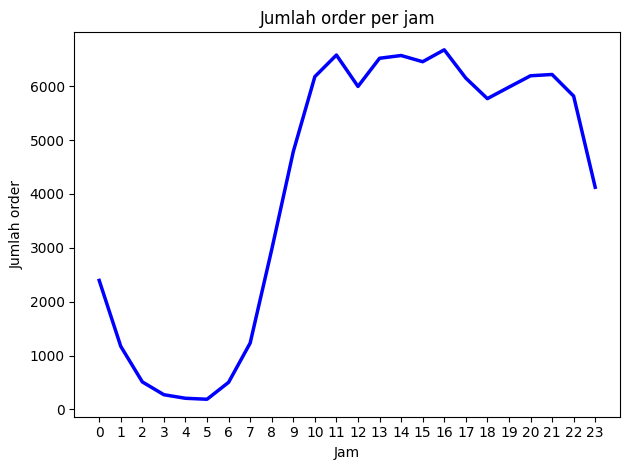

In [62]:
hour_counts = orders['hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['hour', 'count']

sns.lineplot(data=hour_counts, x='hour', y='count', color='blue', linewidth=2.5)
plt.title('Jumlah order per jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah order')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

### Korelasi Delivery Delay (Keterlambatan) vs Rating Review  

In [63]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

print(orders['delivery_delay'].describe())

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64


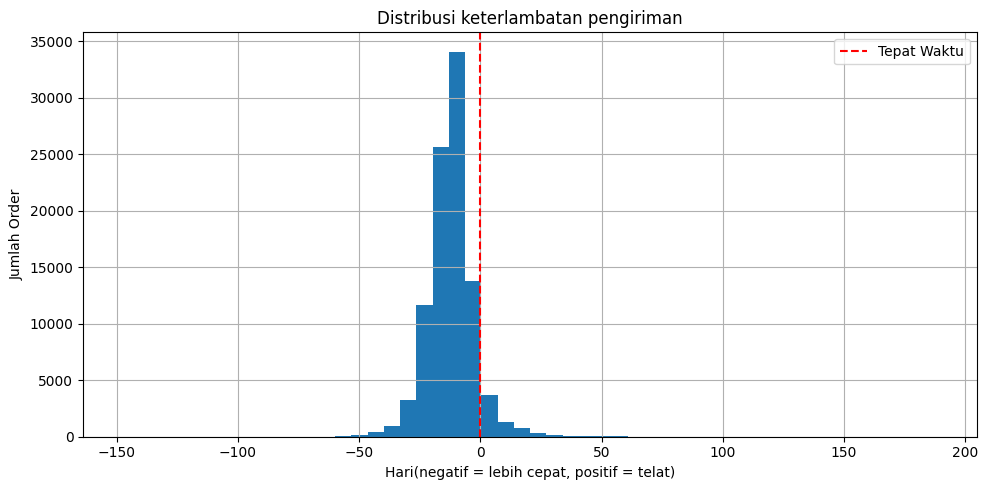

In [64]:
orders['delivery_delay'].hist(bins=50, figsize=(10,5))
plt.title('Distribusi keterlambatan pengiriman')
plt.xlabel('Hari(negatif = lebih cepat, positif = telat)')
plt.ylabel('Jumlah Order')
plt.axvline(x=0, color='red', linestyle='--', label='Tepat Waktu')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
print(order_reviews['review_score'].value_counts().sort_index())
print('---')
print(order_reviews['review_score'].describe())

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64
---
count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64


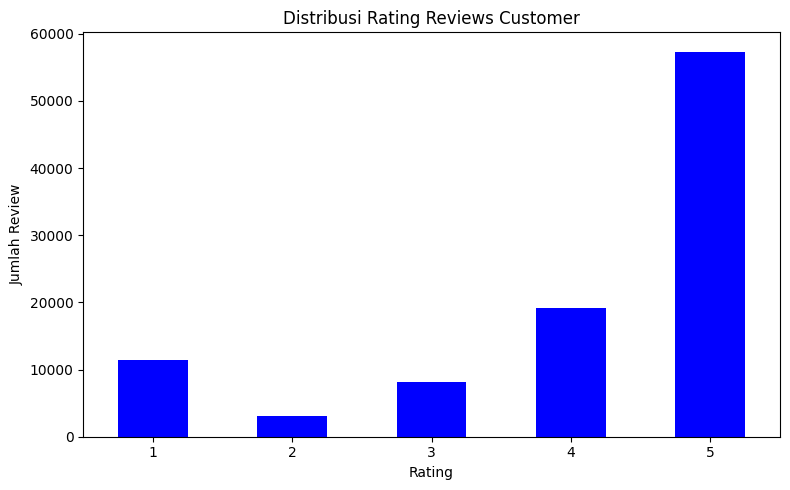

In [66]:
order_reviews['review_score'].value_counts().sort_index().plot(kind='bar', figsize=(8,5), color='blue')
plt.title('Distribusi Rating Reviews Customer')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
order_reviewx = orders.merge(order_reviews, on='order_id', how='inner')

print(order_reviews.shape)
print(order_reviews.head())

(99224, 7)
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3

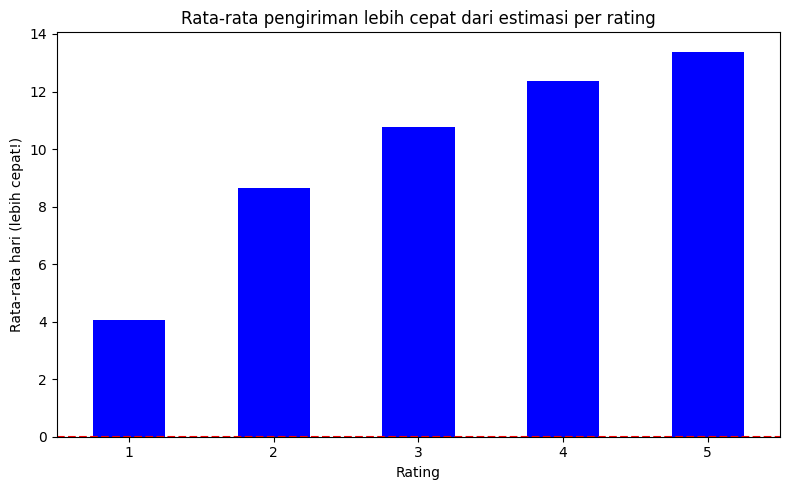

In [73]:
(order_reviewx.groupby('review_score')['delivery_delay'].mean() * -1).plot(kind='bar', figsize=(8,5), color='blue')
plt.title('Rata-rata pengiriman lebih cepat dari estimasi per rating')
plt.xlabel('Rating')
plt.ylabel('Rata-rata hari (lebih cepat!)')
plt.xticks(rotation=0)
plt.axhline(y=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

### Trend Order per Hari

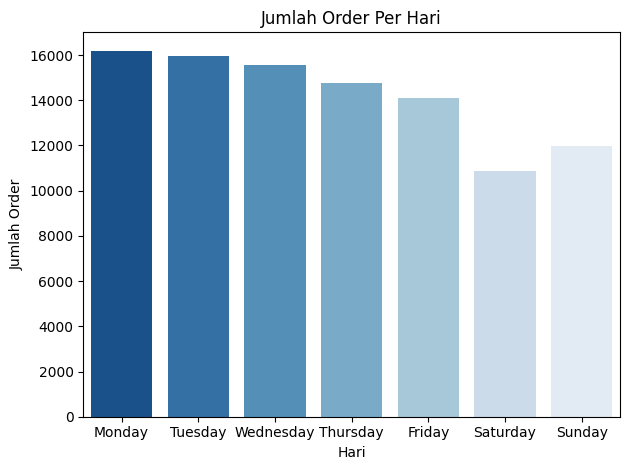

In [74]:
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = orders['day_of_week'].value_counts()[day_order].reset_index()
day_counts.columns = ['day', 'count']

sns.barplot(data=day_counts, x='day', y='count', hue='day', palette='Blues_r', legend=False)
plt.title('Jumlah Order Per Hari')
plt.xlabel('Hari')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analisis Metode Payment yang Digunakan

In [70]:
print(order_payment['payment_type'].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


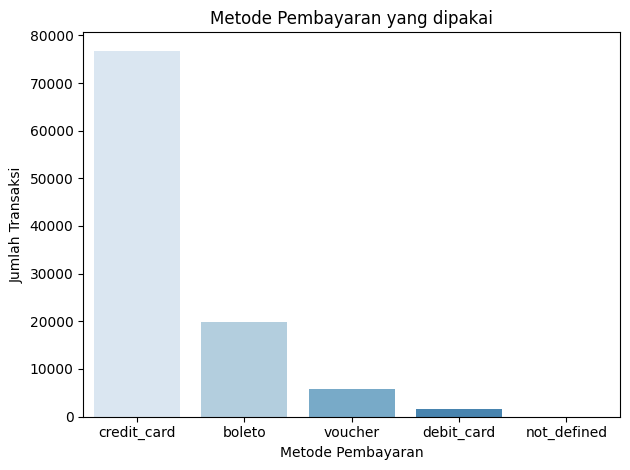

In [75]:
payment_counts = order_payment['payment_type'].value_counts().reset_index()
payment_counts.columns = ['payment_type', 'count']

sns.barplot(data=payment_counts, x='payment_type', y='count', hue='payment_type', palette='Blues', legend=False)
plt.title('Metode Pembayaran yang dipakai')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.tight_layout()
plt.show()

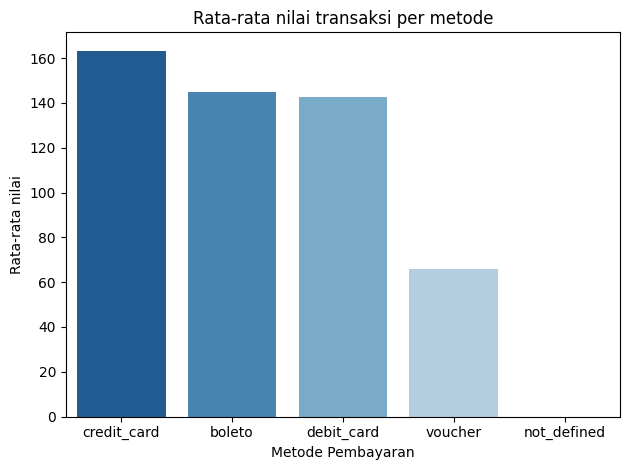

In [72]:
avg_payment = order_payment.groupby('payment_type')['payment_value'].mean().reset_index()
avg_payment.columns = ['payment_type', 'avg_value']
avg_payment = avg_payment.sort_values('avg_value', ascending=False)

sns.barplot(data=avg_payment, x='payment_type', y='avg_value', hue = 'payment_type', palette='Blues_r', legend=False)
plt.title('Rata-rata nilai transaksi per metode')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Rata-rata nilai')
plt.tight_layout()
plt.show()